# Donut VLM Fine-tuning Notebook

**Donut** (Document Understanding Transformer)는 OCR 없이 문서 이미지를 직접 이해하는 Vision-Language Model입니다.

- 인코더: Swin Transformer (이미지 → feature)
- 디코더: mBART (feature → JSON 텍스트 시퀀스)
- 학습 방식: Teacher Forcing을 사용한 Seq2Seq

### Fine-tuning이란?

| 단계 | 누가 | 무엇으로 | 목적 |
|------|------|----------|------|
| **사전학습** (Pretraining) | NAVER | 대규모 문서 이미지 | 범용 문서 표현 학습 |
| **파인튜닝** (Fine-tuning) | 우리 | 내 도메인 데이터 | 특정 태스크에 맞게 가중치 조정 |

이 노트북은 `naver-clova-ix/donut-base` 사전학습 모델을 베이스로,
커스텀 데이터셋(영수증, 양식 등)에 맞게 **파인튜닝**하는 전체 과정을 다룹니다.

### 실행 순서
1. 환경 확인
2. 설정 (Config)
3. 모델 & 프로세서 로드
4. 데이터셋 구성 & 시각화
5. 학습 (Fine-tuning)
6. 평가 (Evaluation)
7. 추론 (Inference)

## Donut 파인튜닝 과정 상세 설명

---

### 1. 전체 흐름 한눈에 보기

```
    [이미지 입력]                     [정답 JSON]
           │                               │
           ▼                               ▼
  ┌─────────────────┐           ┌──────────────────┐
  │  DonutProcessor │           │   json2token()   │
  │  resize / norm  │           │   dict → token   │
  └────────┬────────┘           └────────┬─────────┘
           │ pixel_values                │ target_seq
           └──────────────┬──────────────┘
                          ▼
       ╔══════════════════════════════════════╗
       ║      VisionEncoderDecoderModel       ║
       ║                                      ║
       ║  ┌─────────────────┐  ┌───────────┐  ║
       ║  │     Swin-T      │─▶│   mBART    │  ║
       ║  │    (Encoder)    │  │ (Decoder) │  ║
       ║  └─────────────────┘  └─────┬─────┘  ║
       ╚═════════════════════════════╧════════╝
                                     │ logits
                                     ▼
                           CrossEntropyLoss
                                     │
                                     ▼
                          역전파 / 가중치 업데이트
```

---

### 2. 각 구성 요소 역할

| 구성 요소 | 역할 | 출력 형태 |
|:---|:---|:---|
| **DonutProcessor** | 이미지 리사이즈 → `[1280×960]`, 픽셀 정규화 `[-1, 1]` | `(C, H, W)` 텐서 |
| **Swin Transformer** | 이미지를 패치 단위로 분석, 시각적 특징 추출 | `(seq_len, hidden_dim)` |
| **mBART Decoder** | 인코더 feature + 이전 토큰 → 다음 토큰 예측 | 토큰 시퀀스 |
| **json2token()** | Python dict → `<s_key>value</s_key>` XML 형식 변환 | 문자열 |
| **token2json()** | 생성된 토큰 시퀀스 → Python dict 역변환 | dict |

---

### 3. Teacher Forcing — 학습 방식

| 구분 | 추론 시 (자유 생성) | 학습 시 (Teacher Forcing) |
|:---:|:---|:---|
| **다음 입력** | 이전 **예측** 토큰 사용 | 이전 **정답** 토큰 사용 |
| **특징** | 오류가 누적될 수 있음 | 안정적이고 빠른 학습 |
| **예시** | `<s_total>` → `1200` → ... (틀려도 진행) | `<s_total>` → `12500` → ... (항상 정답 제공) |

---

### 4. Loss 계산 — 모델이 무엇을 배우는가

```python
# 정답 레이블 (labels)
[<s_total>, 1, 2, 5, 0, 0, </s_total>, PAD, PAD ...]
    →  token ids: [102, 49, 50, 53, 48, 48, 103, -100, -100 ...]
                                                  ^^^^^^^^^^^^
                                            패딩: -100으로 마스킹 → loss 제외

# CrossEntropyLoss
loss = -log(P(정답 토큰))     # 정답 토큰의 예측 확률이 높을수록 loss 감소
```

> **핵심:** loss가 낮아진다 = 모델이 정답 토큰을 더 높은 확률로 예측하게 됨

---

### 5. 파인튜닝 vs 처음부터 학습 (From Scratch)

| 항목 | ✅ 파인튜닝 | ❌ From Scratch |
|:---|:---:|:---:|
| 시작 가중치 | 사전학습 완료 (문서 이해 능력 보유) | 랜덤 초기화 |
| 필요 데이터 | 수백 ~ 수천 장 | 수십만 장 이상 |
| 학습 시간 | 수 시간 ~ 수 일 | 수 주 ~ 수 개월 |
| GPU 비용 | 낮음 | 매우 높음 |
| 권장 상황 | **대부분의 실무** | 완전히 새로운 도메인 |

> **결론:** 실무에서는 거의 항상 파인튜닝을 사용합니다.

---

### 6. 학습 중 모니터링 지표

| 지표 | 의미 | 정상 패턴 | 이상 신호 |
|:---|:---|:---:|:---:|
| `train_loss` | 학습 데이터 오차 | 지속 감소 ↘ | 감소 없이 진동 |
| `eval_loss` | 검증 데이터 오차 | 감소 후 수렴 | **증가 시작** → 과적합 |
| `grad_norm` | 그래디언트 크기 | 안정적 유지 | 급격히 증가 → 폭발 |

```
loss
  │
8 │ ╲
6 │  ╲
4 │   ╲──╮
2 │      ╰──────────── ← 수렴 (이상적)
  │                  ╰── eval_loss 증가 시 → 과적합
  └──────────────────────────────── step
     초기 급감        수렴 구간
```

**과적합 방지 설정:**
- `save_total_limit=3` — 최신 체크포인트 3개만 유지
- `load_best_model_at_end=True` — 학습 종료 후 eval_loss 최저 모델 자동 복원

## 📌 코드 성격: "순수 PyTorch" 아님
PyTorch 위에 올라간 **Hugging Face 고수준 파이프라인**. 학습 루프(`for epoch`/`loss.backward()`/`optimizer.step()`)를 직접 짜지 않고 **`Seq2SeqTrainer`**가 역전파·bf16·체크포인트·평가를 모두 처리한다.
스택: `transformers`·`datasets`·`wandb`·`torch`. 직접 작성한 건 `DonutDataset`과 `json2token`/`token2json` 정도이고, PyTorch는 HF 내부(`nn.Module`·`Dataset`)에 깔려 있다.

> 🔹 **환경 점검** — 위젯 렌더러 비활성화 및 PyTorch/Transformers 버전·GPU(CUDA) 상태 확인

In [1]:
# ── widget 렌더러 오류 방지 (VS Code Jupyter) ─────────────────────
# tqdm.auto 및 HuggingFace 내부 progress bar가 ipywidget을
# 사용하지 않도록 강제합니다 — 텍스트 모드로 출력됩니다.
import os
os.environ['TQDM_NOTEBOOK'] = 'false'
os.environ['TOKENIZERS_PARALLELISM'] = 'false'  # tokenizer 경고 억제

# ── Step 0: 환경 확인 ──────────────────────────────────────────────
# 학습에 필요한 라이브러리 버전과 GPU 상태를 먼저 점검합니다.
# CUDA가 False이면 GPU를 인식하지 못한 것 — 드라이버/환경을 확인하세요.
import torch
import transformers
import platform

print(f"Python     : {platform.python_version()}")
print(f"PyTorch    : {torch.__version__}")
print(f"Transformers: {transformers.__version__}")
print(f"CUDA 사용   : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU        : {torch.cuda.get_device_name(0)}")
    print(f"VRAM       : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Python     : 3.10.19
PyTorch    : 2.11.0+cu130
Transformers: 4.57.6
CUDA 사용   : True
GPU        : NVIDIA GB10
VRAM       : 130.7 GB


> 🔹 필수 패키지(datasets·sentencepiece) 설치 확인 및 자동 설치

In [2]:
# ── 필수 패키지 설치 확인 ─────────────────────────────────────────
# 이미 설치된 경우 무시됩니다 — 매번 실행해도 안전합니다.
# datasets  : HuggingFace 데이터셋 다운로드 라이브러리
# sentencepiece : Donut 토크나이저가 내부적으로 사용하는 형태소 분석기
import importlib, subprocess, sys

required = {"datasets": "datasets", "sentencepiece": "sentencepiece"}
missing  = [pkg for mod, pkg in required.items() if importlib.util.find_spec(mod) is None]

if missing:
    print(f"설치 중: {missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing, "-q"])
    print("설치 완료 — 커널을 재시작하지 않아도 됩니다.")
else:
    print("모든 패키지 설치 확인 ✓")


모든 패키지 설치 확인 ✓


> 🔹 공통 라이브러리 import (json·torch·PIL·transformers Donut 등)

In [3]:
# ── 공통 Import ───────────────────────────────────────────────────
import json       # JSON 파일 읽기/쓰기
import os         # 파일 경로, 디렉터리 생성
import random     # 데이터셋 셔플 및 시드 고정
import re         # 정규표현식 (토큰 파싱에 사용)
import shutil
import tempfile
from pathlib import Path  # 운영체제 독립적인 파일 경로 처리

import numpy as np         # 수치 연산 및 시드 고정
from PIL import Image      # 이미지 파일 열기/변환
# tqdm.auto는 VS Code Jupyter에서 ipywidget 오류를 유발하므로 tqdm 직접 사용
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader  # 커스텀 데이터셋 클래스

from transformers import (
    DonutProcessor,              # 이미지 전처리 + 텍스트 토크나이저 통합 유틸리티
    VisionEncoderDecoderModel,   # 인코더(Swin-T) + 디코더(mBART) 통합 모델
    Seq2SeqTrainer,              # Seq2Seq 학습 자동화 (forward/backward/저장)
    Seq2SeqTrainingArguments,    # 학습 하이퍼파라미터 설정
)

# ── matplotlib 전역 스타일 설정 ────────────────────────────────────
# 흰 배경에서도 텍스트/축/선이 선명하게 보이도록 전역 적용
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({
    "figure.facecolor": "white",   # 그림 배경 흰색
    "axes.facecolor":   "white",   # 축 영역 배경 흰색
    "savefig.facecolor":"white",   # 저장 시에도 흰 배경
    "text.color":       "black",   # 모든 텍스트 검정
    "axes.labelcolor":  "black",   # 축 레이블 검정
    "xtick.color":      "black",   # x축 눈금 검정
    "ytick.color":      "black",   # y축 눈금 검정
    "axes.edgecolor":   "black",   # 축 테두리 검정
})

print("Import 완료 ✓  (matplotlib 전역 스타일: 흰 배경 / 검정 텍스트)")


Import 완료 ✓  (matplotlib 전역 스타일: 흰 배경 / 검정 텍스트)


## Step 1 – 설정 (Configuration)

모든 하이퍼파라미터를 딕셔너리로 관리합니다.  
`dataset_name`을 `None`으로 바꾸고 `local_train_dir` / `local_val_dir`을 지정하면 커스텀 데이터셋을 사용할 수 있습니다.

> 🔹 **설정 CFG** — 모델/데이터/학습 하이퍼파라미터 일괄 정의

In [4]:
# ── Step 1: 설정 ──────────────────────────────────────────────────
# 모든 하이퍼파라미터를 한 곳에서 관리합니다.
# 파인튜닝 시 주로 수정하는 항목:
#   - data.dataset_name : None으로 변경 시 로컬 데이터 사용
#   - data.task_prompt  : 내 태스크 이름으로 변경 (예: "<s_receipt>")
#   - training.num_epochs / learning_rate : 데이터 규모에 맞게 조정
CFG = {
    "model": {
        # 사전학습된 Donut 베이스 모델 (HuggingFace Hub)
        # 이 모델을 시작점으로 파인튜닝을 진행합니다
        "pretrained_model_name": "naver-clova-ix/donut-base",
        # 디코더가 한 번에 생성할 수 있는 최대 토큰 수
        # 정답 JSON이 길면 늘려야 합니다 (늘릴수록 메모리 증가)
        "max_length": 768,
        # 인코더 입력 해상도 [height, width]
        # 높을수록 작은 글자도 잘 읽지만 VRAM 소모 증가
        "image_size": [1280, 960],
    },
    "data": {
        # HuggingFace 데이터셋 이름 (None이면 로컬 경로 사용)
        "dataset_name": "naver-clova-ix/cord-v2",
        # 태스크 프롬프트: 디코더가 어떤 태스크를 수행할지 알려주는 시작 토큰
        # 파인튜닝 시 내 태스크 이름으로 반드시 변경하세요
        "task_prompt": "<s_cord-v2>",
        "train_split": "train",
        "val_split": "validation",
        # 로컬 데이터셋 사용 시 아래 경로를 지정 (dataset_name=None 필요)
        # "local_train_dir": "data/processed/train",
        # "local_val_dir":   "data/processed/val",
    },
    "training": {
        "output_dir": "checkpoints",  # 체크포인트 저장 폴더
        "num_epochs": 30,             # 전체 데이터를 몇 번 반복 학습할지
        "batch_size": 2,              # GPU 1개당 한 번에 처리할 샘플 수
        # 실효 배치 크기 = batch_size × gradient_accumulation_steps = 16
        # VRAM이 부족해 batch_size를 작게 설정할 때, 여러 스텝의 gradient를
        # 누적한 뒤 한 번에 업데이트하여 큰 배치 효과를 냅니다
        "gradient_accumulation_steps": 8,
        "learning_rate": 3e-5,   # 가중치를 얼마나 크게 업데이트할지 (너무 크면 발산)
        "warmup_steps": 300,     # 초반 이 스텝 동안 lr을 0 → learning_rate로 서서히 증가
        "weight_decay": 0.01,    # 가중치 L2 정규화 (과적합 방지)
        # Donut(Swin+mBART)은 fp16에서 수치 불안정(NaN/깨짐) → bf16 사용.
        # bf16 적용 여부는 Step 4에서 torch.cuda.is_bf16_supported()로 자동 감지
        # (Ampere+ → bf16, 미지원/CPU → fp32). fp16은 사용하지 않음.
        "fp16": False,
        # CORD-v2(train 800개) 기준 실효배치 16 → epoch당 50스텝, 30 epoch=총 1,500스텝.
        # predict_with_generate=False라 eval은 forward만(가벼움) → logging과 같은 50스텝마다
        # 평가해 train_loss 행마다 eval_loss 행이 따라붙게 함. save도 동일(배수 조건 충족).
        # (저장은 save_total_limit=3이라 최신 3개만 유지 → 디스크 부담 없음)
        "save_steps": 50,        # 몇 스텝마다 체크포인트를 저장할지
        "eval_steps": 50,        # 몇 스텝마다 검증 데이터로 평가할지
        "logging_steps": 50,     # 몇 스텝마다 loss를 출력할지
        "dataloader_num_workers": 4,  # 데이터 로딩 병렬 프로세스 수
        "seed": 42,              # 재현성을 위한 난수 시드
    },
    "wandb": {
        # WandB: 학습 곡선을 웹에서 실시간으로 모니터링하는 도구
        # enabled=True로 바꾸면 wandb.ai에서 그래프를 볼 수 있습니다
        "enabled": False,
        "project": "donut-training",
        "run_name": None,
    },
}

print("Config loaded ✓")
print(f"  모델   : {CFG['model']['pretrained_model_name']}")
print(f"  데이터 : {CFG['data']['dataset_name']}")
print(f"  태스크 : {CFG['data']['task_prompt']}")


Config loaded ✓
  모델   : naver-clova-ix/donut-base
  데이터 : naver-clova-ix/cord-v2
  태스크 : <s_cord-v2>


> 🔹 **시드 고정** — Python·NumPy·PyTorch·CUDA 난수 고정으로 재현성 확보

In [5]:
# ── 재현성을 위한 시드 고정 ────────────────────────────────────────
# 동일한 시드를 설정하면 같은 코드를 다시 실행해도 동일한 결과가 나옵니다.
# Python / NumPy / PyTorch / CUDA 각각의 난수 생성기를 모두 고정해야 합니다.
def set_seed(seed: int):
    random.seed(seed)        # Python 기본 random 모듈
    np.random.seed(seed)     # NumPy 난수
    torch.manual_seed(seed)  # CPU 연산 난수
    torch.cuda.manual_seed_all(seed)  # GPU 연산 난수 (멀티GPU 포함)

set_seed(CFG["training"]["seed"])
print(f"Seed = {CFG['training']['seed']} 고정 완료")


Seed = 42 고정 완료


## [선택] 로컬 데이터셋 준비

HuggingFace 데이터셋을 사용한다면 이 셀은 **건너뛰세요**.

커스텀 이미지+JSON 쌍으로 학습할 경우 아래 셀을 실행하면 `train/val` 분리 및 디렉터리 구조 생성이 자동으로 이루어집니다.

**입력 형식**
```
data/raw/
    doc_001.png
    doc_001.json   ← {"field": "value", ...}
    doc_002.jpg
    doc_002.json
```

**출력 형식** (DonutDataset 로컬 모드와 호환)
```
data/processed/
    train/images/  train/labels/
    val/images/    val/labels/
```

> 🔹 **[선택] 로컬 데이터셋 준비** — 이미지+JSON 쌍을 train/val로 분리·정리

In [6]:
# ── [선택] 로컬 데이터셋 준비 ────────────────────────────────────
# HuggingFace 데이터셋을 사용하면 이 셀을 건너뛰세요.
# 커스텀 이미지+JSON 쌍을 train/val로 분리하고 DonutDataset이 읽을 수 있는
# 디렉터리 구조(images/ + labels/)로 정리합니다.
import shutil
from pathlib import Path

# ↓ 이 두 줄만 수정하세요
SRC_DIR   = Path("data/raw")        # 원본 이미지+JSON 디렉터리
OUT_DIR   = Path("data/processed")  # 정리된 데이터 출력 디렉터리
VAL_RATIO = 0.1                     # 검증셋 비율 (0.1 = 10%)
SEED      = CFG["training"]["seed"]

IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".tiff", ".bmp"}

# 이미지-라벨 쌍 수집: 이미지와 같은 이름의 .json 파일이 있는 것만 포함
pairs = []
for img in sorted(SRC_DIR.glob("*")):
    if img.suffix.lower() not in IMAGE_EXTS:
        continue
    label = SRC_DIR / (img.stem + ".json")
    if label.exists():
        pairs.append((img, label))

if not pairs:
    print(f"이미지+JSON 쌍을 찾을 수 없습니다: {SRC_DIR}")
else:
    # 셔플 후 앞 n_val개를 검증셋, 나머지를 학습셋으로 분리
    random.seed(SEED)
    random.shuffle(pairs)
    n_val       = max(1, int(len(pairs) * VAL_RATIO))
    val_pairs   = pairs[:n_val]
    train_pairs = pairs[n_val:]

    # train/val 각각 images/ labels/ 하위폴더에 파일 복사
    for split_name, split_pairs in [("train", train_pairs), ("val", val_pairs)]:
        img_dir = OUT_DIR / split_name / "images"
        lbl_dir = OUT_DIR / split_name / "labels"
        img_dir.mkdir(parents=True, exist_ok=True)
        lbl_dir.mkdir(parents=True, exist_ok=True)
        for img_path, lbl_path in split_pairs:
            shutil.copy2(img_path, img_dir / img_path.name)
            shutil.copy2(lbl_path, lbl_dir / lbl_path.name)

    print(f"완료: train {len(train_pairs)}개 / val {len(val_pairs)}개")
    print(f"출력: {OUT_DIR}")

    # CFG를 로컬 모드로 자동 전환 (dataset_name=None이면 로컬 경로 사용)
    CFG["data"]["dataset_name"]    = None
    CFG["data"]["local_train_dir"] = str(OUT_DIR / "train")
    CFG["data"]["local_val_dir"]   = str(OUT_DIR / "val")
    print(f"\nCFG 자동 업데이트 완료 — task_prompt는 직접 수정하세요:")
    print(f"  CFG['data']['task_prompt'] = '<s_YOUR_TASK>'")


이미지+JSON 쌍을 찾을 수 없습니다: data/raw


## Step 2 – 모델 & 프로세서 로드

- **DonutProcessor**: 이미지 전처리(resize/normalize) + 텍스트 토크나이저를 하나로 묶은 유틸리티
- **VisionEncoderDecoderModel**: 인코더(Swin-T) + 디코더(mBART) 결합 모델

태스크 프롬프트 토큰(`<s_cord-v2>` 등)을 토크나이저에 추가한 뒤 임베딩 레이어를 확장합니다.

> 🔹 **모델·프로세서 빌드** — Donut 가중치 로드, 해상도/max_length 재설정

In [7]:
# ── Step 2: 모델 & 프로세서 빌드 ─────────────────────────────────
def build_model_and_processor(cfg):
    # 모델 정보 및 설정값 추출
    model_cfg  = cfg["model"]
    name       = model_cfg["pretrained_model_name"]
    image_size = model_cfg["image_size"]    # [height, width]
    max_length = model_cfg["max_length"]

    # 1. 사전학습 모델 및 프로세서(HuggingFace Hub)를 불러온다
    processor = DonutProcessor.from_pretrained(name, use_fast=False)
    model     = VisionEncoderDecoderModel.from_pretrained(name)

    # 2. 입력 이미지 해상도 및 디코더 max length 재설정
    #    (사전학습과 다를 시 아래 모두 수정 필요)
    processor.image_processor.size = {"height": image_size[0], "width": image_size[1]}
    processor.image_processor.do_align_long_axis = False  # 세로 이미지 원본대로 사용
    model.config.encoder.image_size = image_size
    model.config.decoder.max_length = max_length

    # 3. 태스크 프롬프트 및 필드 토큰을 토크나이저에 등록 & 임베딩 확장
    task_prompt = cfg["data"]["task_prompt"]

    def _collect_keys(obj, ks):
        # JSON 내 모든 key를 찾는 재귀함수
        if isinstance(obj, dict):
            for k, v in obj.items():
                ks.add(k)
                _collect_keys(v, ks)
        elif isinstance(obj, list):
            for v in obj:
                _collect_keys(v, ks)

    # 데이터셋 라벨에서 등장하는 모든 key 수집
    keys     = set()
    data_cfg = cfg["data"]
    if data_cfg.get("dataset_name"):  # HuggingFace 기반 데이터셋(원격)
        from datasets import load_dataset
        raw = load_dataset(data_cfg["dataset_name"])
        for split in (data_cfg["train_split"], data_cfg["val_split"]):
            for gt_str in raw[split]["ground_truth"]:  # 이미지 디코드 없이 key만 수집
                gt = json.loads(gt_str)
                _collect_keys(gt.get("gt_parse", gt), keys)
                # print(keys)
    else:   # 로컬 데이터셋
        for d in (data_cfg.get("local_train_dir"), data_cfg.get("local_val_dir")):
            if not d: continue
            for jp in sorted((Path(d) / "labels").glob("*.json")):
                _collect_keys(json.load(open(jp, encoding="utf-8")), keys)

    # <s_필드>/<\/s_필드> 토큰화
    field_tokens = []
    for k in sorted(keys):
        field_tokens += [f"<s_{k}>", f"</s_{k}>"]
        # print(field_tokens)

    # 태스크 토큰, <sep/> (리스트 구분), 필드 토큰을 특수토큰으로 지정
    special_tokens = list(dict.fromkeys(
        re.findall(r"<[^>]+>", task_prompt) + ["<sep/>"] + field_tokens
    ))
    num_added = processor.tokenizer.add_special_tokens({
        "additional_special_tokens": special_tokens
    })
    if num_added:
        # 토크나이저 크기에 맞게 임베딩 테이블 확장
        model.decoder.resize_token_embeddings(len(processor.tokenizer))
    print(f"  특수 토큰 추가: {num_added}개 (필드 키 {len(keys)}종)")

    # 4. 디코더 패딩/시작 토큰 id 세팅
    # generation_config 기본 max_length가 20이라, 옵션 없이 generate() 호출 시
    # 20토큰에서 잘림 → 학습 max_length로 맞춰 latent 함정 제거
    model.generation_config.max_length = max_length
    model.config.pad_token_id = processor.tokenizer.pad_token_id
    model.config.decoder_start_token_id = processor.tokenizer.convert_tokens_to_ids(
        [task_prompt]
    )[0]

    # VisionEncoderDecoderModel은 클래스명이 LOSS_MAPPING과 매칭 안 돼 loss_type이
    # None으로 잡힘 → "loss_type=None ... unrecognized" 경고. 기본 fallback과 동일한
    # 인과적 LM 손실을 명시해 경고를 제거 (동작 변화 없음, ForCausalLMLoss).
    model.loss_type = "ForCausalLM"

    return model, processor

# 모델 및 프로세서 빌드 (CFG에 따라)
model, processor = build_model_and_processor(CFG)

# 5. 디바이스 할당: GPU(CUDA) 가능시 사용, 그렇지 않으면 CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = model.to(device)

# 파라미터 수 출력 (엔코더/디코더)
enc_params = sum(p.numel() for p in model.encoder.parameters()) / 1e6
dec_params = sum(p.numel() for p in model.decoder.parameters()) / 1e6
print(f"디바이스       : {device}")
print(f"인코더 파라미터: {enc_params:.1f}M  (Swin Transformer — 이미지 특징 추출)")
print(f"디코더 파라미터: {dec_params:.1f}M  (mBART — 토큰 시퀀스 생성)")
print(f"Decoder start token: {processor.tokenizer.convert_ids_to_tokens([model.config.decoder_start_token_id])}")


The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


  특수 토큰 추가: 55개 (필드 키 27종)
디바이스       : cuda
인코더 파라미터: 74.2M  (Swin Transformer — 이미지 특징 추출)
디코더 파라미터: 127.7M  (mBART — 토큰 시퀀스 생성)
Decoder start token: ['<s_cord-v2>']


## Step 3 – 데이터셋 구성 & 시각화

### DonutDataset 동작 원리

| 입력 | 처리 | 출력 |
|------|------|------|
| PIL Image | DonutProcessor → pixel_values | `(C, H, W)` Tensor |
| JSON ground truth | Tokenizer → teacher-forcing label | `(max_length,)` Token IDs |

**패딩 토큰 → -100**: CrossEntropyLoss는 `-100`으로 표시된 위치를 자동으로 무시합니다 (패딩 위치에서 loss 계산 안 함).

### 사용 가능한 데이터셋

#### 기본 제공 (HuggingFace 자동 다운로드)

| 데이터셋 | 태스크 | 크기 | HuggingFace ID |
|---------|--------|------|----------------|
| **CORD-v2** | 영수증 정보 추출 | train 800 / val 100 / test 100 | `naver-clova-ix/cord-v2` |
| **DocVQA** | 문서 질의응답 | train 10,194 / val 1,286 | `naver-clova-ix/docvqa_en` |
| **RVL-CDIP** | 문서 분류 (16종) | train 320,000 / val 40,000 | `rvl_cdip` |

데이터셋 페이지: https://huggingface.co/datasets/naver-clova-ix/cord-v2

`CFG`에서 ID만 바꾸면 자동으로 다운로드됩니다:
```python
# CORD-v2 (기본값 — 영수증)
CFG["data"]["dataset_name"] = "naver-clova-ix/cord-v2"
CFG["data"]["task_prompt"]  = "<s_cord-v2>"

# DocVQA (문서 질의응답)
CFG["data"]["dataset_name"] = "naver-clova-ix/docvqa_en"
CFG["data"]["task_prompt"]  = "<s_docvqa>"

# 커스텀 로컬 데이터셋
CFG["data"]["dataset_name"]    = None
CFG["data"]["local_train_dir"] = "data/processed/train"
CFG["data"]["local_val_dir"]   = "data/processed/val"
CFG["data"]["task_prompt"]     = "<s_receipt>"   # 원하는 이름
```

> 🔹 **DonutDataset 정의** — json2token 변환 및 커스텀 Dataset 클래스

In [8]:
# ── Step 3a: DonutDataset 정의 ────────────────────────────────────

def json2token(obj, sort_keys=True):
    '''dict/list → Donut 토큰 시퀀스 변환.

    Donut의 정답은 JSON을 XML 스타일 토큰으로 표현합니다.
    예) {"total": "12500"} → <s_total>12500</s_total>
        {"items": [{"nm": "A"}]} → <s_items><s_nm>A</s_nm></s_items>

    sort_keys=True : 키를 역순 정렬하여 항상 동일한 순서를 보장합니다.
    '''
    if isinstance(obj, dict):
        output = ""
        keys = sorted(obj.keys(), reverse=True) if sort_keys else obj.keys()
        for k in keys:
            # 재귀 호출로 중첩 dict/list도 처리
            output += f"<s_{k}>" + json2token(obj[k], sort_keys) + f"</s_{k}>"
        return output
    elif isinstance(obj, list):
        # 리스트 항목은 <sep/> 토큰으로 구분
        return "<sep/>".join([json2token(v, sort_keys) for v in obj])
    else:
        return str(obj)


class DonutDataset(Dataset):
    '''HuggingFace 데이터셋 split 또는 로컬 디렉터리를 Donut 학습용으로 변환.

    로컬 디렉터리 레이아웃:
        <root>/
            images/   *.png / *.jpg
            labels/   *.json   (이미지와 동일한 파일명 stem)
    '''

    def __init__(self, dataset_or_root, processor, max_length: int, task_prompt: str):
        self.processor   = processor
        self.max_length  = max_length
        self.task_prompt = task_prompt

        # 입력 타입에 따라 HuggingFace 모드 / 로컬 모드를 자동 선택
        if isinstance(dataset_or_root, (str, Path)):
            self.samples = self._load_local(Path(dataset_or_root))
            self.mode    = "local"
        else:
            self.hf_dataset = dataset_or_root
            self.mode       = "hf"

    def _load_local(self, root: Path):
        # images/와 labels/ 폴더에서 같은 파일명을 가진 쌍을 찾아 리스트로 반환
        image_exts = {".png", ".jpg", ".jpeg", ".tiff", ".bmp"}
        samples = []
        for img_path in sorted((root / "images").glob("*")):
            if img_path.suffix.lower() not in image_exts:
                continue
            label_path = root / "labels" / (img_path.stem + ".json")
            if label_path.exists():
                samples.append((img_path, label_path))
        return samples

    def __len__(self):
        return len(self.hf_dataset) if self.mode == "hf" else len(self.samples)

    def __getitem__(self, idx):
        # ── 이미지와 정답 시퀀스 준비 ────────────────────────────
        if self.mode == "hf":
            sample = self.hf_dataset[idx]
            image  = sample["image"].convert("RGB")
            gt     = json.loads(sample["ground_truth"])
            if "gt_parse" in gt:
                # gt_parse는 이미 dict → json2token()으로 토큰 시퀀스 변환
                # 예: <s_cord-v2><s_total>12500</s_total>...</s_cord-v2>EOS
                target_seq = (
                    self.task_prompt
                    + json2token(gt["gt_parse"])
                    + self.processor.tokenizer.eos_token  # 문장 끝 토큰
                )
            else:
                target_seq = self.task_prompt + self.processor.tokenizer.eos_token
        else:
            img_path, label_path = self.samples[idx]
            image = Image.open(img_path).convert("RGB")
            with open(label_path) as f:
                gt = json.load(f)
            target_seq = (
                self.task_prompt
                + json2token(gt)
                + self.processor.tokenizer.eos_token
            )

        # ── 이미지 → pixel_values ────────────────────────────────
        # DonutProcessor가 이미지를 지정 해상도로 리사이즈하고
        # 픽셀 값을 [-1, 1] 범위로 정규화합니다.
        # squeeze(0): 배치 차원 제거 → (1, C, H, W) → (C, H, W)
        pixel_values = self.processor(
            image, return_tensors="pt"
        ).pixel_values.squeeze(0)

        # ── 정답 텍스트 → label token IDs ────────────────────────
        # Teacher Forcing 학습을 위해 정답 시퀀스를 토큰 ID로 변환합니다.
        # padding="max_length" : 짧은 시퀀스를 max_length까지 패딩 토큰으로 채움
        # truncation=True      : max_length를 초과하면 잘라냄
        labels = self.processor.tokenizer(
            target_seq,
            add_special_tokens=False,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        ).input_ids.squeeze(0)

        # 패딩 위치를 -100으로 마스킹
        # CrossEntropyLoss는 target=-100인 위치를 자동으로 무시합니다.
        # 즉, 의미 없는 패딩 토큰에서는 loss가 계산되지 않습니다.
        labels[labels == self.processor.tokenizer.pad_token_id] = -100

        return {
            "pixel_values":    pixel_values,   # 모델 입력 이미지
            "labels":          labels,          # Teacher Forcing 정답 레이블
            "target_sequence": target_seq,      # 평가 시 문자열 비교용
        }

print("DonutDataset 클래스 정의 완료 ✓")


DonutDataset 클래스 정의 완료 ✓


> 🔹 **데이터셋 로드** — HuggingFace 또는 로컬에서 train/val 데이터셋 구성

In [9]:
# ── Step 3b: 데이터셋 로드 ────────────────────────────────────────
# CFG 설정에 따라 HuggingFace 또는 로컬 디렉터리에서 데이터를 로드합니다.
# dataset_name이 지정되면 인터넷에서 자동 다운로드하고,
# None이면 local_train_dir / local_val_dir 경로를 사용합니다.
def build_datasets(cfg, processor):
    data_cfg   = cfg["data"]
    max_length = cfg["model"]["max_length"]
    prompt     = data_cfg["task_prompt"]

    if data_cfg.get("dataset_name"):          # HuggingFace 데이터셋
        from datasets import load_dataset
        # load_dataset은 처음 실행 시 다운로드 후 로컬에 캐시합니다
        raw      = load_dataset(data_cfg["dataset_name"])
        train_ds = DonutDataset(raw[data_cfg["train_split"]], processor, max_length, prompt)
        val_ds   = DonutDataset(raw[data_cfg["val_split"]],   processor, max_length, prompt)
    else:                                      # 로컬 디렉터리
        train_ds = DonutDataset(data_cfg["local_train_dir"], processor, max_length, prompt)
        val_ds   = DonutDataset(data_cfg["local_val_dir"],   processor, max_length, prompt)

    return train_ds, val_ds


train_ds, val_ds = build_datasets(CFG, processor)
print(f"Train 샘플 수: {len(train_ds):,}")
print(f"Val   샘플 수: {len(val_ds):,}")


Train 샘플 수: 800
Val   샘플 수: 100


> 🔹 **샘플 시각화** — 학습 이미지와 정답 토큰 시퀀스를 눈으로 확인

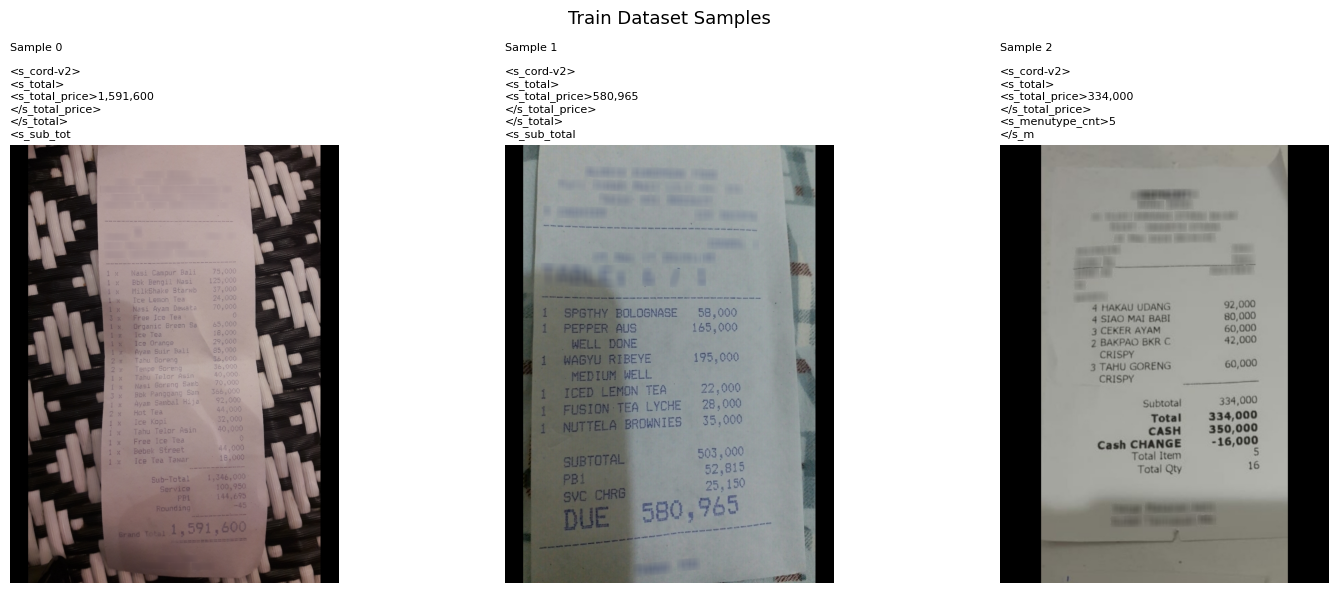


샘플 0 — 유효 토큰 수: 375 / 512
  (나머지 137개는 패딩 — loss 계산 제외)


In [10]:
# ── Step 3c: 샘플 시각화 ──────────────────────────────────────────
# 학습 데이터가 올바르게 로드됐는지 눈으로 확인합니다.
# 이미지와 해당 정답 토큰 시퀀스를 함께 출력합니다.
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for i, ax in enumerate(axes):
    sample = train_ds[i]

    # pixel_values는 [-1, 1]로 정규화되어 있으므로
    # matplotlib으로 보려면 [0, 1] 범위로 되돌려야 합니다.
    img_tensor = sample["pixel_values"]
    img_np     = (img_tensor.permute(1, 2, 0).numpy() + 1) / 2  # [-1,1] → [0,1]
    img_np     = img_np.clip(0, 1)  # 범위 초과값 방지

    ax.imshow(img_np)
    ax.axis("off")

    # 정답 시퀀스가 너무 길어 잘라서 표시 (앞 80자)
    # "<" 앞에 줄바꿈을 넣어 토큰 구조를 읽기 쉽게 만듭니다
    gt_short = sample["target_sequence"][:80].replace("<", "\n<")
    ax.set_title(f"Sample {i}\n{gt_short}", fontsize=8, loc="left")

plt.suptitle("Train Dataset Samples", fontsize=13)
plt.tight_layout()
plt.show()

# 유효 토큰 수 확인: -100이 아닌 위치 = 실제 정답 토큰 수
# max_length(512) 중 실제 정보가 몇 토큰인지 파악할 수 있습니다
valid_tokens = (train_ds[0]["labels"] != -100).sum().item()
print(f"\n샘플 0 — 유효 토큰 수: {valid_tokens} / {CFG['model']['max_length']}")
print(f"  (나머지 {CFG['model']['max_length'] - valid_tokens}개는 패딩 — loss 계산 제외)")


## Step 4 – 학습 (Training)

`Seq2SeqTrainer`를 사용합니다.

| 주요 옵션 | 설명 |
|-----------|------|
| `predict_with_generate=True` | 평가 시 모델이 실제로 토큰을 생성하여 metric 계산 |
| `fp16=True` | Mixed Precision — VRAM을 약 40% 절감 |
| `gradient_accumulation_steps` | 실효 배치를 크게 유지하면서 VRAM 절감 |
| `load_best_model_at_end=True` | 학습 종료 후 val loss 최저 체크포인트를 자동 복원 |

> 🔹 **학습 실행** — Seq2SeqTrainer로 파인튜닝 및 체크포인트 저장

In [11]:
# ── Step 4: 학습 실행 ─────────────────────────────────────────────
# Seq2SeqTrainer가 다음을 자동으로 처리합니다:
#   - 매 스텝: forward → loss 계산 → backward → 가중치 업데이트
#   - 매 eval_steps: 검증셋으로 eval_loss 측정
#   - 매 save_steps: 체크포인트 저장
#   - 학습 완료 후: eval_loss 최소 체크포인트 자동 복원
if CFG["wandb"]["enabled"]:
    import wandb
    wandb.init(
        project=CFG["wandb"]["project"],
        name=CFG["wandb"]["run_name"],
        config=CFG,
    )

tcfg = CFG["training"]

# bf16은 Ampere 이상 GPU에서만 지원 → 런타임에 자동 감지.
# 미지원(또는 CPU)이면 fp32로 학습 (fp16은 Donut 수치 불안정이라 사용 안 함).
use_bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
print(f"bf16 사용: {use_bf16}" + ("" if use_bf16 else "  (미지원 → fp32 학습)"))

training_args = Seq2SeqTrainingArguments(
    output_dir                  = tcfg["output_dir"],
    num_train_epochs            = tcfg["num_epochs"],
    per_device_train_batch_size = tcfg["batch_size"],
    per_device_eval_batch_size  = tcfg["batch_size"],
    gradient_accumulation_steps = tcfg["gradient_accumulation_steps"],
    learning_rate               = tcfg["learning_rate"],
    warmup_steps                = tcfg["warmup_steps"],   # 초반 lr 웜업 구간
    weight_decay                = tcfg["weight_decay"],   # 과적합 방지 정규화
    fp16                        = tcfg["fp16"],           # fp16 금지(Donut 수치 불안정)
    bf16                        = use_bf16,    # Ampere+ 자동 감지 (torch.cuda.is_bf16_supported)
    save_steps                  = tcfg["save_steps"],
    eval_steps                  = tcfg["eval_steps"],
    logging_steps               = tcfg["logging_steps"],
    save_total_limit            = 3,          # 가장 최신 체크포인트 3개만 보관
    eval_strategy               = "steps",    # transformers ≥4.45 변경된 파라미터명
    predict_with_generate       = False,      # best 기준이 eval_loss라 generation 불필요 → eval 속도↑
    dataloader_num_workers      = tcfg["dataloader_num_workers"],
    report_to                   = ["wandb"] if CFG["wandb"]["enabled"] else ["none"],
    load_best_model_at_end      = True,       # 학습 후 eval_loss 최저 모델 자동 복원
    metric_for_best_model       = "eval_loss",
    greater_is_better           = False,      # loss는 낮을수록 좋음
    disable_tqdm                = False,
    logging_first_step          = True,       # 첫 스텝도 로그에 남겨 초기값 확인
)

# ── Step별 loss history를 한 줄씩 누적 출력하는 콜백 ──────────────
from transformers import TrainerCallback

class LossHistoryPrinter(TrainerCallback):
    """train_loss / eval_loss가 기록될 때마다 한 줄씩 출력해
    loss가 지속적으로 감소하는지 step 단위로 확인할 수 있게 한다.
    (노트북 기본 HTML 표는 덮어쓰기 갱신이라 추이가 안 남으므로 print로 누적)"""
    def __init__(self):
        self._header_printed = False

    def _header(self):
        if not self._header_printed:
            print(f"{'step':>7} | {'epoch':>6} | {'train_loss':>11} | {'eval_loss':>10}")
            print("-" * 46)
            self._header_printed = True

    def on_log(self, args, state, control, logs=None, **kwargs):
        # train_loss만 처리 (eval_loss는 on_evaluate에서 별도 처리)
        if logs is None or "loss" not in logs:
            return
        self._header()
        epoch = logs.get("epoch", state.epoch or 0.0)
        print(f"{state.global_step:>7} | {epoch:>6.2f} | "
              f"{logs['loss']:>11.4f} | {'-':>10}")

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics is None or "eval_loss" not in metrics:
            return
        self._header()
        epoch = metrics.get("epoch", state.epoch or 0.0)
        print(f"{state.global_step:>7} | {epoch:>6.2f} | "
              f"{'-':>11} | {metrics['eval_loss']:>10.4f}")

trainer = Seq2SeqTrainer(
    model         = model,
    args          = training_args,
    train_dataset = train_ds,
    eval_dataset  = val_ds,
    callbacks     = [LossHistoryPrinter()],
)

# 실효 배치 크기 = batch_size × gradient_accumulation_steps
print(f"실효 배치 크기: {tcfg['batch_size']} × {tcfg['gradient_accumulation_steps']} = "
      f"{tcfg['batch_size'] * tcfg['gradient_accumulation_steps']}")
print(f"저장 경로    : {tcfg['output_dir']}")
print("\n학습 시작... (loss가 지속적으로 감소하는지 확인하세요)")
trainer.train()

# 학습이 끝난 뒤 전체 로그 history를 표로 한 번 더 정리해서 출력
import pandas as pd
hist = pd.DataFrame(trainer.state.log_history)
cols = [c for c in ["step", "epoch", "loss", "eval_loss", "learning_rate"] if c in hist.columns]
print("\n=== 전체 로그 history ===")
with pd.option_context("display.max_rows", None):
    print(hist[cols].to_string(index=False))

# 최종 모델과 프로세서를 함께 저장합니다.
# 추론 시 같은 경로에서 둘 다 로드해야 합니다.
final_dir = os.path.join(tcfg["output_dir"], "final")
trainer.save_model(final_dir)
processor.save_pretrained(final_dir)
print(f"\n학습 완료! 모델 저장됨 → {final_dir}")

실효 배치 크기: 2 × 8 = 16
저장 경로    : checkpoints

학습 시작... (loss가 지속적으로 감소하는지 확인하세요)


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss,Validation Loss


   step |  epoch |  train_loss |  eval_loss
----------------------------------------------
      1 |   0.02 |     15.8666 |          -
     50 |   1.00 |     13.0747 |          -


KeyboardInterrupt: 

## Step 5 – 평가 (Evaluation)

**Leaf-Match Score**: 예측 JSON과 정답 JSON의 모든 리프(leaf) 값을 비교하여 일치율을 계산합니다.  
(완전한 TED 구현을 원하면 `zss` 패키지를 사용하세요)

> 🔹 **평가 유틸리티** — token2json 역변환 등 평가 보조 함수 정의

In [ ]:
# ── Step 5a: 평가 유틸리티 ────────────────────────────────────────

def token2json(tokens: str) -> dict | str:
    '''모델이 생성한 토큰 시퀀스를 Python dict로 역변환.

    json2token()의 반대 과정입니다.
    예) "<s_total>12500</s_total>" → {"total": "12500"}

    정규표현식으로 <s_key>...</s_key> 패턴을 찾아 재귀적으로 파싱합니다.
    '''
    output = {}
    while tokens:
        # 여는 태그 <s_key> 탐색
        start = re.search(r"<s_(.+?)>", tokens)
        if not start:
            break
        key     = start.group(1)
        end_pat = f"</s_{key}>"
        end_pos = tokens.find(end_pat, start.end())
        if end_pos == -1:
            break
        value = tokens[start.end():end_pos]
        # 값 안에 중첩 태그가 있으면 재귀 호출로 파싱
        output[key] = token2json(value) if "<s_" in value else value.strip()
        tokens = tokens[end_pos + len(end_pat):]
    return output if output else tokens.strip()


def compute_leaf_match(pred: dict, gt: dict) -> float:
    '''예측 JSON과 정답 JSON의 최말단(leaf) 값 일치율을 계산합니다 (0~1).

    중첩 구조를 평탄화(flatten)한 뒤 경로별로 값을 비교합니다.
    예) {"menu": {"nm": "Burger"}} → {"/menu/nm": "Burger"}
    전체 정답 leaf 중 예측이 맞춘 비율을 반환합니다.
    '''
    def flatten(d, prefix=""):
        items = {}
        if isinstance(d, dict):
            for k, v in d.items():
                items.update(flatten(v, f"{prefix}/{k}"))
        elif isinstance(d, list):
            for i, v in enumerate(d):
                items.update(flatten(v, f"{prefix}[{i}]"))
        else:
            items[prefix] = str(d)
        return items

    pred_flat = flatten(pred)
    gt_flat   = flatten(gt)
    if not gt_flat:
        return 1.0 if not pred_flat else 0.0
    matches = sum(pred_flat.get(k) == v for k, v in gt_flat.items())
    return matches / len(gt_flat)  # 일치한 leaf 수 / 전체 정답 leaf 수

print("평가 유틸리티 정의 완료 ✓")


평가 유틸리티 정의 완료 ✓


> 🔹 **검증셋 전체 평가** — 체크포인트 로드 후 Leaf-Match Score 계산

In [ ]:
# ── Step 5b: Validation set 전체 평가 ────────────────────────────
# ※ 학습이 완료된 뒤 실행하세요.
# 저장된 체크포인트를 로드하고 검증 데이터 전체에 대해 추론을 수행한 뒤
# Leaf-Match Score(정답 필드 일치율)를 계산합니다.

CHECKPOINT     = os.path.join(CFG["training"]["output_dir"], "final")
MAX_NEW_TOKENS = 768  # 생성할 최대 토큰 수 (학습의 max_length=768과 일치)
EVAL_BATCH     = 1    # 평가는 배치 1로 해도 속도 차이가 크지 않음

# 저장된 체크포인트가 있으면 로드, 없으면 현재 메모리의 model 사용
if os.path.isdir(CHECKPOINT):
    eval_processor = DonutProcessor.from_pretrained(CHECKPOINT, use_fast=False)
    eval_model     = VisionEncoderDecoderModel.from_pretrained(CHECKPOINT).to(device)
    eval_model.tie_weights()  # lm_head ↔ embed_tokens 재결합 (이미 자동이지만 명시; missing-key 경고 무해)
else:
    print(f"체크포인트 없음: {CHECKPOINT} — 현재 model 사용")
    eval_model, eval_processor = model, processor

eval_model.eval()  # Dropout, BatchNorm 등을 평가 모드로 전환

# 디코더의 첫 입력 토큰: task_prompt를 ID로 변환
# 이 토큰을 시작으로 모델이 이후 토큰을 자유롭게 생성합니다
task_prompt = CFG["data"]["task_prompt"]
decoder_input_ids = eval_processor.tokenizer(
    task_prompt, add_special_tokens=False, return_tensors="pt"
).input_ids.to(device)

val_loader = DataLoader(val_ds, batch_size=EVAL_BATCH, shuffle=False, num_workers=2)

scores = []
with torch.inference_mode():  # 그래디언트 계산 비활성화 → 메모리 절약, 속도 향상
    for batch in tqdm(val_loader, desc="Evaluating"):
        pixel_values = batch["pixel_values"].to(device)

        # generate(): 이미지를 보고 EOS 토큰이 나올 때까지 토큰을 하나씩 생성
        # early_stopping=True: EOS 토큰 등장 시 즉시 생성 종료
        # use_cache=True: 이전 KV 캐시를 재사용하여 생성 속도 향상
        outputs = eval_model.generate(
            pixel_values,
            decoder_input_ids = decoder_input_ids.expand(pixel_values.size(0), -1),
            max_new_tokens    = MAX_NEW_TOKENS,
            early_stopping    = True,
            pad_token_id      = eval_processor.tokenizer.pad_token_id,
            eos_token_id      = eval_processor.tokenizer.eos_token_id,
            use_cache         = True,
        )

        for i, seq in enumerate(outputs):
            # 생성된 토큰 ID를 문자열로 디코딩 후 특수 토큰 제거
            pred_str  = eval_processor.batch_decode([seq], skip_special_tokens=False)[0]
            pred_str  = pred_str.replace(eval_processor.tokenizer.eos_token, "")                                 .replace(eval_processor.tokenizer.pad_token, "").strip()
            pred_str  = pred_str.replace(task_prompt, "")  # ★ task 토큰 제거 (안 떼면 token2json이 dict 대신 문자열 반환 → 점수 0)
            pred_json = token2json(pred_str)  # 문자열 → dict 변환

            # 정답도 동일하게 전처리
            gt_str  = batch["target_sequence"][i]
            gt_str  = gt_str.replace(task_prompt, "")                             .replace(eval_processor.tokenizer.eos_token, "")
            gt_json = token2json(gt_str)

            # 둘 다 dict이면 leaf 일치율, 아니면 문자열 완전 일치로 평가
            if isinstance(pred_json, dict) and isinstance(gt_json, dict):
                scores.append(compute_leaf_match(pred_json, gt_json))
            else:
                scores.append(1.0 if pred_str.strip() == gt_str.strip() else 0.0)

mean_score = sum(scores) / len(scores) if scores else 0.0
print(f"\n평가 완료 — {len(scores)} 샘플")
print(f"Leaf-Match Score: {mean_score:.4f} ({mean_score*100:.2f}%)")
print("  (1.0 = 모든 필드 완벽 일치 / 0.0 = 전혀 불일치)")


Evaluating:   0%|          | 0/100 [00:00<?, ?it/s]The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Evaluating: 100%|██████████| 100/100 [01:09<00:00,  1.44it/s]


평가 완료 — 100 샘플
Leaf-Match Score: 0.8060 (80.60%)
  (1.0 = 모든 필드 완벽 일치 / 0.0 = 전혀 불일치)


## Step 6 – 추론 (Inference)

이미지 파일 한 장을 넣으면 JSON 결과를 반환합니다.

> 🔹 **단일 이미지 추론** — 학습된 모델로 새 이미지에서 JSON 생성

Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


추론 결과:
{
  "total": {
    "total_price": "45,500",
    "changeprice": "4,500",
    "cashprice": "50,000"
  },
  "menu": {
    "price": "16,000",
    "nm": "PIZZA TOAST",
    "cnt": "1"
  }
}


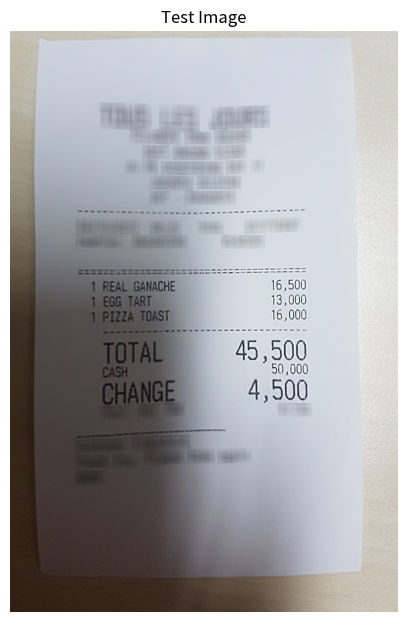

In [ ]:
# ── Step 6: 단일 이미지 추론 ──────────────────────────────────────
# 새 이미지 한 장을 입력하면 학습된 모델이 JSON을 생성합니다.
# 학습 때와 달리 정답 없이 모델이 스스로 토큰을 생성(자유 생성)합니다.
@torch.inference_mode()
def predict(image_path: str, task: str | None = None) -> dict:
    '''이미지 경로를 받아 추출된 정보를 dict로 반환.

    Args:
        image_path: 추론할 이미지 파일 경로
        task      : 태스크 프롬프트 (None이면 CFG 값 자동 사용)
    '''
    task = task or CFG["data"]["task_prompt"]

    # 이미지를 모델 입력 형태로 전처리
    image        = Image.open(image_path).convert("RGB")
    pixel_values = eval_processor(image, return_tensors="pt").pixel_values.to(device)

    # 디코더 시작 토큰: task_prompt를 첫 입력으로 제공
    decoder_ids = eval_processor.tokenizer(
        task, add_special_tokens=False, return_tensors="pt"
    ).input_ids.to(device)

    # 토큰 생성: EOS 토큰이 나올 때까지 자동으로 반복
    outputs = eval_model.generate(
        pixel_values,
        decoder_input_ids = decoder_ids,
        max_new_tokens    = 768,
        early_stopping    = True,
        pad_token_id      = eval_processor.tokenizer.pad_token_id,
        eos_token_id      = eval_processor.tokenizer.eos_token_id,
        use_cache         = True,
    )

    # 토큰 ID → 문자열 → EOS/PAD 제거 → dict 변환
    sequence = eval_processor.batch_decode(outputs, skip_special_tokens=False)[0]
    sequence = sequence.replace(eval_processor.tokenizer.eos_token, "") \
                       .replace(eval_processor.tokenizer.pad_token, "").strip()
    sequence = sequence.replace(task, "")  # ★ task 토큰 제거 (안 떼면 token2json이 dict 대신 문자열 반환)
    return token2json(sequence)


# ── 사용 예시 ─────────────────────────────────────────────────────
# image_path = "data/test/sample.png"  # ← 실제 이미지 경로로 변경
# result = predict(image_path)
# print(json.dumps(result, indent=2, ensure_ascii=False))

# 검증셋 첫 번째 샘플로 빠른 동작 확인
if CFG["data"].get("dataset_name"):
    from datasets import load_dataset
    raw_val    = load_dataset(CFG["data"]["dataset_name"], split=CFG["data"]["val_split"])
    test_image = raw_val[0]["image"]
else:
    test_image = Image.open(val_ds.samples[0][0])

# PIL Image를 임시 파일로 저장 후 predict 호출
import tempfile
with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as tmp:
    test_image.save(tmp.name)
    result = predict(tmp.name)

print("추론 결과:")
print(json.dumps(result, indent=2, ensure_ascii=False))

# 이미지 시각화
fig, ax = plt.subplots(figsize=(5, 8))
ax.imshow(test_image)
ax.axis("off")
ax.set_title("Test Image")
plt.show()


---
## 파인튜닝(Fine-tuning)이란?

사전학습된 Donut 모델(`donut-base`)을 베이스로, 내 도메인 데이터에 맞게 가중치를 추가 학습하는 과정입니다.

```
사전학습 (Pretraining)               파인튜닝 (Fine-tuning)
────────────────────────             ────────────────────────────────
대규모 문서 이미지로                   내 도메인 데이터 (영수증, 양식 등)
범용 표현 학습                         → 특정 태스크에 맞게 가중치 조정
(NAVER가 이미 완료)                    (우리가 하는 것)
```

---

## 커스텀 데이터셋으로 파인튜닝하기 — 단계별 가이드

### 1단계. 데이터 준비

이미지 파일과 JSON 정답 파일을 **같은 이름**으로 `data/raw/` 폴더에 넣습니다.

```
data/raw/
    영수증_001.jpg
    영수증_001.json
    영수증_002.jpg
    영수증_002.json
    ...
```

JSON 정답 파일 예시:
```json
{
    "store_name": "스타벅스",
    "total": "12500",
    "items": [
        {"name": "아메리카노", "price": "4500"},
        {"name": "카페라떼",  "price": "8000"}
    ]
}
```

---

### 2단계. train / val 자동 분리

**[선택] 로컬 데이터셋 준비** 셀에서 경로를 수정하고 실행합니다.

```python
# ↓ 이 두 줄만 수정하세요
SRC_DIR = Path("/home/user/my_receipts")  # 내 데이터 폴더 (절대경로 권장)
OUT_DIR = Path("data/processed")          # 결과 저장 위치
VAL_RATIO = 0.1                           # 검증셋 비율 (10%)
```

실행 결과:
```
완료: train 90개 / val 10개
출력: data/processed
CFG 자동 업데이트 완료
```

---

### 3단계. 태스크 이름 & CFG 설정

**Step 1 설정 셀**의 `CFG`를 아래와 같이 수정합니다.

```python
CFG = {
    "model": {
        "pretrained_model_name": "naver-clova-ix/donut-base",  # 그대로 유지
        "max_length": 512,
        "image_size": [1280, 960],
    },
    "data": {
        "dataset_name": None,                        # ← None으로 변경 (로컬 모드)
        "task_prompt": "<s_receipt>",                # ← 내 태스크 이름으로 변경
        "local_train_dir": "data/processed/train",   # ← 2단계에서 생성된 경로
        "local_val_dir":   "data/processed/val",
    },
    "training": {
        "output_dir": "checkpoints",
        "num_epochs": 50,          # ← 데이터 수백 장: 50~100 / 수천 장: 10~30
        "batch_size": 2,
        "gradient_accumulation_steps": 8,
        "learning_rate": 3e-5,
        "warmup_steps": 300,
        "fp16": True,
        ...
    },
}
```

태스크 이름 예시:
```python
"task_prompt": "<s_receipt>",   # 영수증
"task_prompt": "<s_invoice>",   # 세금계산서
"task_prompt": "<s_form>",      # 일반 양식
"task_prompt": "<s_idcard>",    # 신분증
```

---

### 4단계. Step 1부터 순서대로 재실행

| 순서 | 셀 | 하는 일 |
|:----:|----|---------|
| 1 | **Step 1** 설정 | 수정한 CFG 반영 |
| 2 | **Step 2** 모델 로드 | 새 태스크 토큰 자동 추가 |
| 3 | **Step 3b** 데이터셋 로드 | 로컬 데이터 읽기 |
| 4 | **Step 4** 학습 | 파인튜닝 시작 → `checkpoints/` 에 저장 |
| 5 | **Step 5** 평가 | Leaf-Match Score 확인 |
| 6 | **Step 6** 추론 | 새 이미지로 결과 확인 |

학습 완료 후 추론 예시:
```python
result = predict("새_영수증.jpg")
print(result)
# → {"store_name": "스타벅스", "total": "12500", "items": [...]}
```

> **에폭 · 학습률 조정 팁**
> - 데이터 수백 장: `num_epochs: 50~100`, `learning_rate: 3e-5`
> - 데이터 수천 장: `num_epochs: 10~30`, `learning_rate: 3e-5`
> - loss가 수렴하지 않으면 `warmup_steps`를 늘리거나 `learning_rate`를 낮춰보세요.